# FYP: Driver Behavior Scoring - Training with Real Data

This notebook trains the Random Forest model using **preprocessed real datasets** (English).

**Datasets Used:** `data/cleaned/all_drivers_combined.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Load Cleaned Dataset

In [2]:
# Load the preprocessed English dataset
df = pd.read_csv('data/cleaned/all_drivers_combined.csv')

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Total rows: 555,000

Columns: ['speed', 'rpm', 'throttle', 'engine_load', 'driver_id']

First 5 rows:


,speed,rpm,throttle,engine_load,driver_id
0,0,890,13.7,18.0,1
1,0,890,13.7,17.6,1
2,0,890,13.7,17.6,1
3,0,890,13.7,17.6,1
4,0,890,13.7,17.6,1


In [3]:
# Check data quality
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Missing values:
speed          0
rpm            0
throttle       0
engine_load    0
driver_id      0
dtype: int64

Basic statistics:


,speed,rpm,throttle,engine_load,driver_id
count,555000.000000,555000.000000,555000.000000,555000.000000,555000.000000
mean,53.060142,2060.768771,27.227515,37.505999,2.040000
std,33.185378,679.339149,15.797336,32.742429,0.817062
min,0.000000,652.000000,13.700000,0.000000,1.000000
25%,22.000000,1612.000000,13.700000,9.100000,1.000000
50%,55.000000,2082.000000,22.700000,28.200000,2.000000
75%,82.000000,2534.000000,34.900000,63.500000,3.000000
max,136.000000,3831.000000,79.200000,100.000000,3.000000


## Step 2: Create Labels (Aggressive vs Safe)

In [4]:
# Create derived features
df['speed_change'] = df['speed'].diff().abs()
df['throttle_jerk'] = df['throttle'].diff().abs()

# Create labels using research-based thresholds
df['label'] = 0  # Default: Safe

aggressive_mask = (
    ((df['rpm'] > 3000) & (df['throttle'] > 70)) |
    (df['speed_change'] > 15)
)

df.loc[aggressive_mask, 'label'] = 1  # Aggressive

df = df.dropna()

print(f"Safe driving samples: {(df['label'] == 0).sum():,}")
print(f"Aggressive driving samples: {(df['label'] == 1).sum():,}")

Safe driving samples: 217,896
Aggressive driving samples: 337,103


## Step 3: Feature Engineering

In [5]:
# Rolling window features
window = 5
df['speed_mean'] = df['speed'].rolling(window=window).mean()
df['speed_std'] = df['speed'].rolling(window=window).std()
df['rpm_mean'] = df['rpm'].rolling(window=window).mean()

df = df.dropna()

print(f"Final dataset size: {len(df):,} rows")
df.head()

Final dataset size: 554,995 rows


,speed,rpm,throttle,engine_load,driver_id,speed_change,throttle_jerk,label,speed_mean,speed_std,rpm_mean
5,0,890,13.7,17.6,1,0.0,0.0,0,0.0,0.0,890.0
6,0,892,13.7,17.6,1,0.0,0.0,0,0.0,0.0,890.4
7,0,892,13.7,17.6,1,0.0,0.0,0,0.0,0.0,890.8
8,0,892,13.7,17.6,1,0.0,0.0,0,0.0,0.0,891.2
9,0,892,13.7,17.6,1,0.0,0.0,0,0.0,0.0,891.6


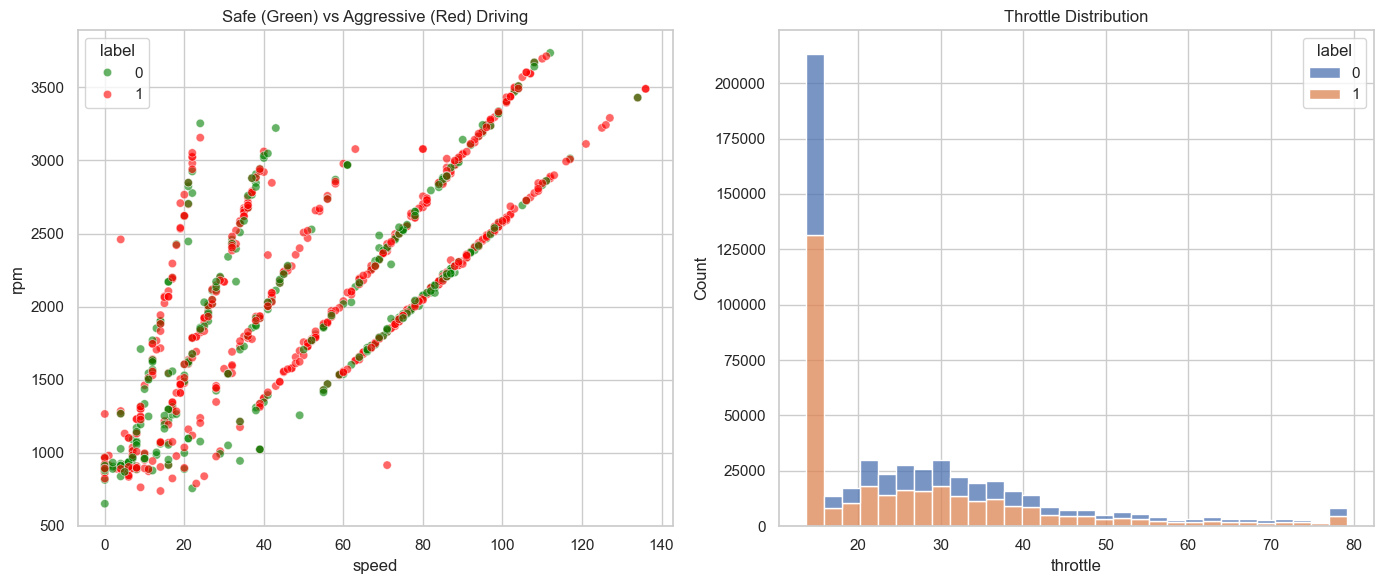

In [6]:
# Visualize patterns
sample = df.sample(min(1000, len(df)))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=sample, x='speed', y='rpm', hue='label', palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title('Safe (Green) vs Aggressive (Red) Driving')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='throttle', hue='label', bins=30, multiple='stack')
plt.title('Throttle Distribution')

plt.tight_layout()
plt.show()

## Step 4: Train Model

In [7]:
# Prepare features
feature_cols = ['speed', 'rpm', 'throttle', 'speed_mean', 'speed_std', 'rpm_mean', 'throttle_jerk']
X = df[feature_cols]
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

Training samples: 443,996
Test samples: 110,999


In [8]:
# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))


🎯 Accuracy: 78.24%

              precision    recall  f1-score   support

        Safe       0.93      0.48      0.64     43578
  Aggressive       0.74      0.98      0.84     67421

    accuracy                           0.78    110999
   macro avg       0.84      0.73      0.74    110999
weighted avg       0.82      0.78      0.76    110999



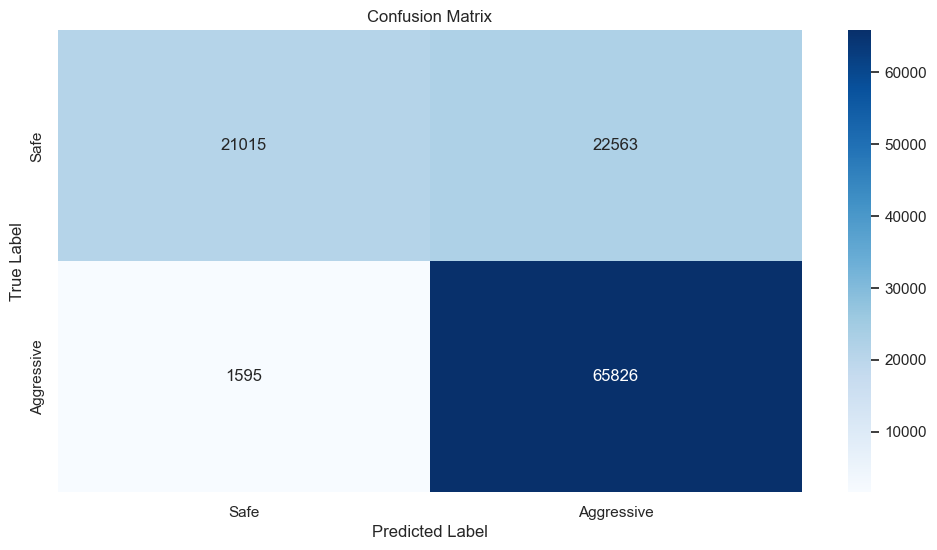

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Aggressive'], yticklabels=['Safe', 'Aggressive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

C:\Users\dhyan\AppData\Local\Temp\ipykernel_15020\387743420.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='viridis')


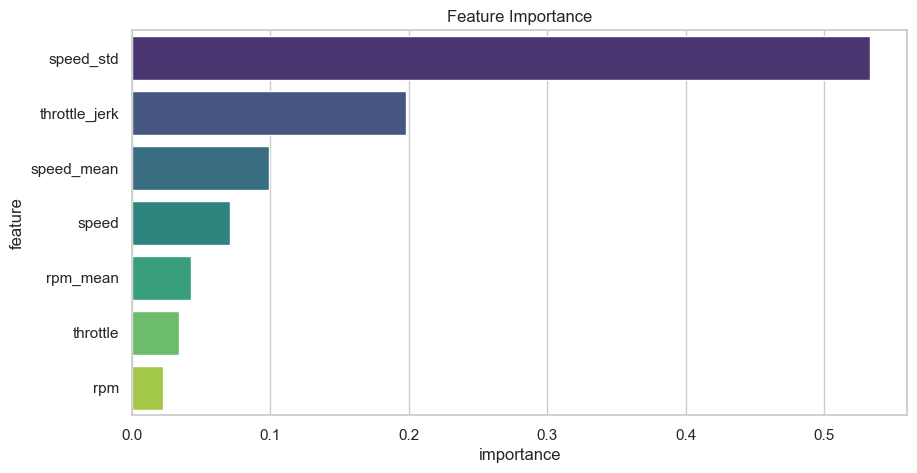

,feature,importance
4,speed_std,0.533417
6,throttle_jerk,0.197780
3,speed_mean,0.099063
0,speed,0.070810
5,rpm_mean,0.042427
2,throttle,0.033947
1,rpm,0.022557


In [10]:
# Feature Importance
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance')
plt.show()

importances

## Step 5: Save Model

In [11]:
# Save the trained model
os.makedirs('src/models', exist_ok=True)
joblib.dump(clf, 'src/models/driver_model.pkl')
print("✅ Model saved to src/models/driver_model.pkl")
print("\nYou can now run: python main.py --mode simulation")

✅ Model saved to src/models/driver_model.pkl

You can now run: python main.py --mode simulation
